# FARGOpy Tutorial: Surface and Volume Integrals

## Analyzing FARGO3D Simulation Data

This notebook demonstrates how to use the `FARGOpy` library to perform advanced calculations and analyses on simulation data from `FARGO3D`. The main focus is on calculating integrals over general surfaces or volumes and visualizing the results, such as accretion rates and density distributions.

You will learn how to:

- Download and load precomputed simulation data.
- Define and visualize surfaces (e.g., spheres) in the simulation domain.
- Interpolate simulation fields onto these surfaces.
- Calculate physical quantities such as mass flux and total mass within a region.
- Visualize results in 2D and 3D.

This notebook serves as a practical guide for users to explore and analyze `FARGO3D` simulation data using `FARGOpy`, focusing on integral-based calculations and their visualization.

## What's in this notebook

- **Data Preparation**: Download and load a precomputed simulation.
- **Surface Definition**: Create and visualize a spherical surface around a planet.
- **Field Interpolation**: Interpolate density and velocity fields onto the surface.
- **Accretion Rate Calculation**: Compute the mass flux through the surface.
- **Visualization**: Plot results in 2D and 3D, including projections.
- **Total Mass Calculation**: Integrate the total mass within the defined region over time.

## Requirements

Before starting, ensure you have the following modules installed:

- `fargopy`
- `numpy`
- `matplotlib`
- `pandas`
- `plotly`
- `cartopy` (for 2D projections)

If you are running this notebook in Google Colab, install the latest version of `fargopy` using the cell below.

In [1]:
# @title Install fargopy
import sys
if 'google.colab' in sys.modules:
    !sudo pip install -Uq fargopy

## Import Required Libraries

Import all necessary Python libraries and enable autoreload for development.

In [2]:
import fargopy as fp
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

%load_ext autoreload
%autoreload 2

## Download and Load Simulation Data

First, list available precomputed simulations and download the 3D simulation of a disk with a Jovian planet.

In [3]:
fp.Simulation.list_precomputed()

fargo:
	Description: Protoplanetary disk with a Jovian planet [2D]
	Size: 55 MB
p3diso:
	Description: Protoplanetary disk with a Super earth planet [3D]
	Size: 220 MB
p3disoj:
	Description: Protoplanetary disk with a Jovian planet [3D]
	Size: 84 MB
fargo_multifluid:
	Description: Protoplanetary disk with several fluids (dust) and a Jovian planet in 2D
	Size: 100 MB
binary:
	Description: Disk around a binary with the properties of Kepler-38 in 2D
	Size: 140 MB


Download, for instance, the 3D simulation of a disk with a Jovian planet:

In [4]:
path=fp.Simulation.download_precomputed('p3disoj')

Downloading...
From: https://docs.google.com/uc?export=download&id=1Xzgk9qatZPNX8mLmB58R9NIi_YQUrHz9
To: /tmp/p3disoj.tgz
100%|██████████| 84.2M/84.2M [00:08<00:00, 9.62MB/s]


Uncompressing p3disoj.tgz into /tmp/p3disoj
Done.


### Connect to the Simulation

Create a `Simulation` object by connecting it to the directory containing the simulation results.

In [6]:
sim = fp.Simulation(output_dir=path)

Your simulation is now connected with '/home/fargopy/fargo3d/'
Now you are connected with output directory '/tmp/p3disoj'
Found a variables.par file in '/tmp/p3disoj', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 128 [[0, np.float64(-3.117048960983623)], [-1, np.float64(3.117048960983623)]]
	Variable r: 64 [[0, np.float64(0.5078125)], [-1, np.float64(1.4921875)]]
	Variable theta: 32 [[0, np.float64(1.4231400767948967)], [-1, np.float64(1.5684525767948965)]]
Number of snapshots in output directory: 11
Planets found in summary.dat:
  Name: Jupiter, Initial pos: [1.0, 0.001, 0.0], Mass: 0.001


### Visualize Simulation Data

Plot an interactive overview of the simulation data to verify successful loading.

In [7]:
sim.plot_interactive()

IntSlider(value=1, description='Snapshot', max=10)

Text(value='theta=1.568', description='Slice')

IntSlider(value=500, description='Res', max=1000, min=50, step=10)

ToggleButton(value=False, description='Interpolate', icon='check')

ToggleButton(value=False, description='Streamlines', icon='random')

...

Dropdown(description='Mapa', options=('Densidad', 'Energia', 'Velocidad'), value='Densidad')

Dropdown(description='Componente v', layout=Layout(display='none'), options=('vx', 'vy', 'vz'), value='vx')

Label(value='')

Button(description='Update', icon='refresh', style=ButtonStyle())

TypeError: cannot unpack non-iterable FieldInterpolator object

### Load Field Data

Load 2D slices of the gas density field for visualization in the XY and XZ planes.

In [8]:
snap = 10 

dataXY = sim.load_field(
    fields='gasdens',
    slice='r=[0.8,1.2],phi=[-25 deg,25 deg],theta=1.568',
    snapshot=snap,
)



dataXZ = sim.load_field(
    fields='gasdens',
    slice='phi=0',
    snapshot=snap,
)

### Load Planet Properties

Extract planet properties from the simulation snapshot. This includes the planet's position and Hill radius.

In [9]:
planets = sim.load_planets(snapshot=snap)

In [10]:
planet0 = planets[0]

We can obtain the hill radius of the planet:

In [11]:
planet0.hill_radius

0.06826246847512232

Now we create a sphere Surface object with center in planet semimajor-axis and radius $R_H$

In [12]:
r_hill = planet0.hill_radius
a = planet0.pos.x

sphere = fp.Surface(type='sphere',radius=r_hill, subdivisions=6, center=(a, 0.0, 0.0),z_cut=0.0003)

In [13]:
type(sphere)

fargopy.flux.Surface

Visualize the sphere object

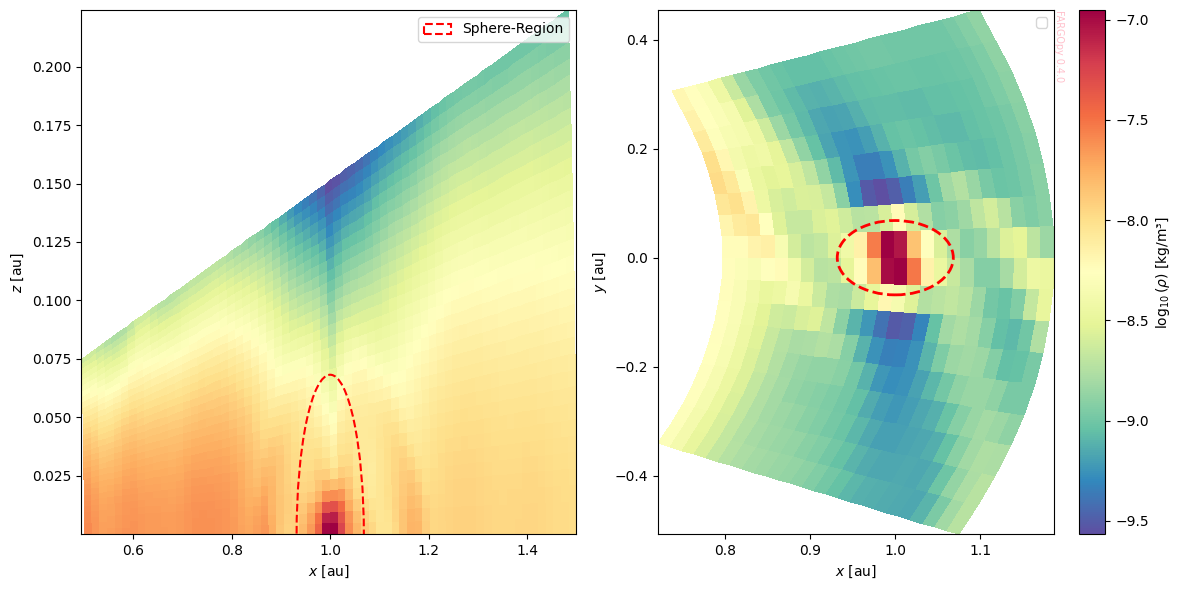

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

cmap = 'Spectral_r'

# Colormap of the logarithmic density for the XZ plane
ax = axs[0]
pc = ax.pcolormesh(
    dataXZ.mesh.x * sim.UL / fp.AU,
    dataXZ.mesh.z * sim.UL / fp.AU,
    np.log10(dataXZ.data * sim.URHO ),
    cmap=cmap
)
ax.set_xlabel('$x$ [au]')
ax.set_ylabel('$z$ [au]')

# Add a circle to the XZ plane
circle_xz = plt.Circle(
    (sphere.center[0], sphere.center[2]),  # Center in the XZ plane
    sphere.radius * sim.UL / fp.AU,        # Radius in AU
    color='red',
    fill=False,
    linestyle='--',
    linewidth=1.5,
    label='Sphere-Region'
)
ax.add_artist(circle_xz)
ax.legend()

# Colormap of the logarithmic density for the XY plane
ax = axs[1]
pc = ax.pcolormesh(
    dataXY.mesh.x * sim.UL / fp.AU,
    dataXY.mesh.y * sim.UL / fp.AU,
    np.log10(dataXY.data * sim.URHO ),
    cmap=cmap
)
ax.set_xlabel('$x$ [au]')
ax.set_ylabel('$y$ [au]')

# Add a circle to the XY plane
circle_xy = plt.Circle(
    (sphere.center[0], sphere.center[1]),  # Center in the XY plane
    sphere.radius * sim.UL / fp.AU,        # Radius in AU
    color='red',
    fill=False,
    linestyle='--',
    linewidth=2,
    
)
ax.add_artist(circle_xy)
ax.legend()

# Add colorbar
fig.colorbar(pc, ax=axs[1], label=r"$\log_{10}(\rho)$ [kg/m³]")
fp.Plot.fargopy_mark(ax)

plt.tight_layout()
plt.show()

## 2D Surface Visualization

Create a semi-spherical surface (filtered for $z>0.03$) and explore its properties.

Create the `Sphere` object filtered for $z>0.03$ (semi-sphere)


In [15]:
sphere = fp.Surface(type='sphere',
    radius=r_hill,
    subdivisions=6,
    center=(a, 0.0, 0.0),
    z_cut=0.003
)



### Surface Properties

The sphere object has several important attributes:

- `sphere.centers`: Array of tessellation triangle centers.
- `sphere.areas`: Array of triangle areas.
- `sphere.volumes`: Array of triangle volumes.

These are used for interpolation and integration.

In [16]:
sphere.centers

array([[0.9618595 , 0.05652429, 0.00306834],
       [0.96273411, 0.05709123, 0.00327984],
       [0.96243954, 0.05691031, 0.00306834],
       ...,
       [1.06323655, 0.02545562, 0.00358049],
       [1.06321634, 0.02556221, 0.0031728 ],
       [1.06306267, 0.0259391 , 0.0031728 ]], shape=(39930, 3))

### Interpolate Fields on the Surface

Interpolate the simulation fields (e.g., density) onto the centers of the surface tessellation.

In [17]:
# Coordinates of the sphere centers
xcs=sphere.centers[:, 0]
ycs=sphere.centers[:, 1]
zcs=sphere.centers[:, 2]

First we can cut the data to the spherical region for flux calculation:


In [18]:
cut_sphere = (planet0.pos.x,planet0.pos.y,planet0.pos.z,2*planet0.hill_radius)

In [19]:
# Load the 3D gas density field from the simulation
data3d = sim.load_field(
    fields='gasdens',
    snapshot=snap,
    cut=cut_sphere, 
    interpolate=True)



In [20]:
rho = data3d.evaluate(
   time=snap,
   var1=xcs,
   var2=ycs,
   var3=zcs,
   interpolator='griddata',
   method='linear')


Lets see the 3D Density field over the surface:

In [21]:
import plotly.graph_objects as go

fig = go.Figure(data=go.Scatter3d(
    x=xcs.flatten(),
    y=ycs.flatten(),
    z=zcs.flatten(),
    mode='markers',
    marker=dict(
        size=2,
        color=np.log(rho.flatten()),  # Color según la densidad interpolada
        colorscale='Spectral_r',
        opacity=1,
        colorbar=dict(title='Density log[g cm^-3]'),
    )
))

fig.update_layout(
    scene=dict(
        xaxis_title='X [au]',
        yaxis_title='Y [au]',
        zaxis_title='Z [au]',
        aspectmode='data'
    ),
    title='Interpolation on Sphere Surface Centers in 3D Gas Density Field',
)

fig.show()

## 2D Projection of Surface Data

Project the surface data onto a 2D map using Mollweide projection for easier visualization of the distribution.

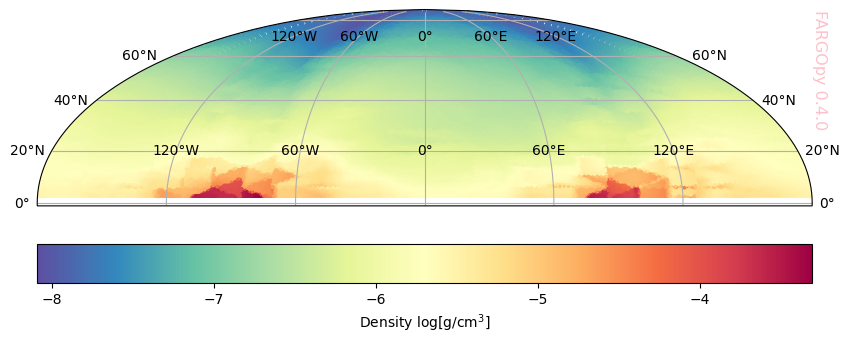

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

x0, y0, z0 = 1, 0, 0
xcs_shifted = xcs - x0
ycs_shifted = ycs - y0
zcs_shifted = zcs - z0

# Calculate the spherical coordinates
r = np.sqrt(xcs_shifted**2 + ycs_shifted**2 + zcs_shifted**2)
lat = np.degrees(np.arcsin(zcs_shifted / r))
lon = np.degrees(np.arctan2(ycs_shifted, xcs_shifted))


fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.Mollweide())
sc = ax.scatter(
    lon, lat, c=np.log(rho), s=2, cmap='Spectral_r',
    transform=ccrs.PlateCarree(), alpha=1
)
# ax.coastlines()  # <- No mostrar contorno
ax.gridlines(draw_labels=True)
fp.Plot.fargopy_mark(ax)

plt.colorbar(sc, orientation='horizontal', pad=0.05, label='Density log[g/cm$^3$]')
plt.show()

# Accretion Rate Calculation

Calculate the accretion rate (mass flux) through the spherical surface around the planet using the interpolated density and velocity fields.

### Define Planet and Surface for Accretion Calculation

Set up the planet and surface objects for the accretion rate calculation.

In [28]:
snap = 10
planet0 = sim.load_planets(snapshot=snap)[0]
r_hill = planet0.hill_radius
a = planet0.pos.x

In [30]:
sphere = fp.Surface(type='sphere',
    radius=r_hill,  
    subdivisions=6, 
    center=(a, 0.0, 0.0),
    z_cut=0.003
)


### Compute Mass Flux Through the Surface

Use the `mass_flux` method to calculate the accretion rate through the surface as a function of time.

In [31]:
flux = sphere.mass_flux(
    sim=sim,
    snapshot=[0, 10],
    follow_planet=True
)



Calculating mass flux:   0%|          | 0/11 [00:00<?, ?it/s]

Calculating mass flux: 100%|██████████| 11/11 [00:55<00:00,  5.03s/it]


### Convert and Plot Accretion Rate

Convert the accretion rate to Jupiter masses per year and plot the result as a function of time.

In [32]:
Msunyr = 1.587e-26
Mjupyr = 1.662e-23

acretion = np.array(flux) * sim.UM/sim.UT * Mjupyr

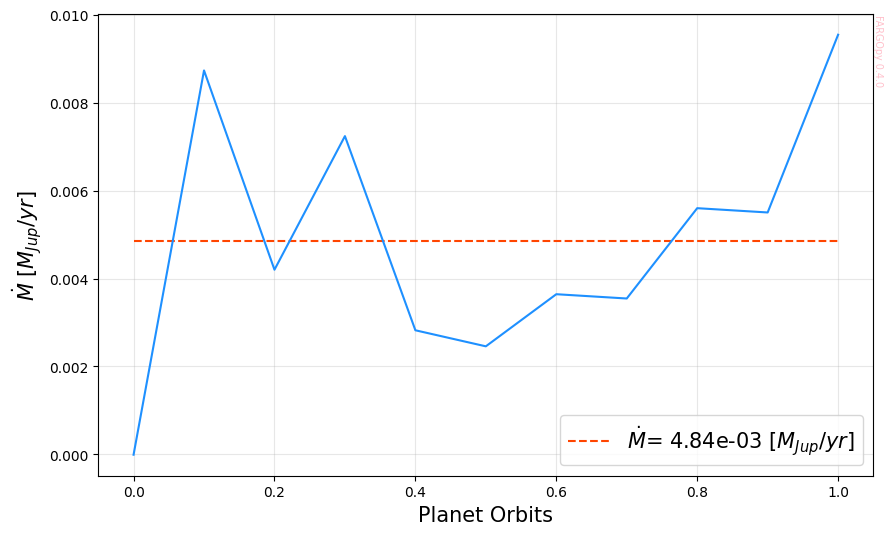

In [33]:
mean= acretion.mean()
ts = np.linspace(0,1,11)

fig,ax=plt.subplots( figsize=(10, 6))
ax.hlines(mean, 0, 1, colors='orangered', linestyles='--', label=r'$\dot{M}$'+ f'= {mean:.2e}'+r'$\ [M_{Jup}/yr]$')
ax.plot(ts,acretion, color='dodgerblue')
ax.set_xlabel('Planet Orbits',size=15)
ax.set_ylabel(r'$\dot{M} \ [M_{Jup}/yr]$',size=15  )
ax.legend(fontsize=15)
fp.Plot.fargopy_mark(ax)
ax.grid(alpha=0.3)

## Matter flux heatmap in a single snapshot

Let's now look at a heat map on the surface of the sphere that shows us how the flow behaves on it.

In [34]:
snap = 10
planet0 = sim.load_planets(snapshot=snap)[0]
r_hill = planet0.hill_radius
x = planet0.pos.x
y = planet0.pos.y
z = planet0.pos.z   

sphere = fp.Surface(type='sphere',
    radius=0.5*r_hill, 
    subdivisions=6, 
    center=(x, y, z),
    z_cut=0.00203
)



### Load Density and Velocity Fields

Load both the density and velocity fields for the region around the planet to compute the local mass flux.

In [36]:
sphere_cut = (x,y,z,3*r_hill)
data = sim.load_field(
    fields=['gasdens','gasv'],
    snapshot = snap,
    interpolate=True,
    cut=sphere_cut
    )


### Interpolate Fields at Surface Centers

Interpolate the density and velocity fields at the centers of the surface tessellation triangles.

In [37]:
xcs = sphere.centers[:, 0]
ycs = sphere.centers[:, 1]
zcs = sphere.centers[:, 2]


rho = data.evaluate(
   field='gasdens',
   time=snap,
   var1=xcs,
   var2=ycs,
   var3=zcs)

vel = data.evaluate(
   field='gasv',
   time=snap,
   var1=xcs,
   var2=ycs,
   var3=zcs
   )

### Calculate Local Mass Flux

Compute the local mass flux at each triangle center using the dot product of velocity and surface normal, weighted by density and area.

array([-9.42253179e-05,  1.00049542e+00,  0.00000000e+00])

In [44]:
# Planet velocity as vector
pds70c = sim.load_planets(snapshot=snap)[0]
vpx = pds70c.vel.x
vpy = pds70c.vel.y
vpz = pds70c.vel.z  

# vel (3, N)
planet_vel = np.array([vpx, vpy, vpz]).reshape(3, 1)

# Relative velocity
vel_rel = vel - planet_vel   # still (3, N)

# Convert to (N,3) for dot product with normals
vel_rel = vel_rel.T          # (N, 3)

v_dot_n = np.sum(vel_rel * sphere.normals, axis=1)

Ms = rho * v_dot_n * sphere.areas
# Convert the mass flux to solar masses per year
M_sy = sim.UM/sim.UL**3 * sim.UL**2 * sim.UL/sim.UT * Ms *1.58667e-26




In [45]:
import plotly.graph_objects as go

fig = go.Figure(data=go.Scatter3d(
    x=xcs.flatten(),
    y=ycs.flatten(),
    z=zcs.flatten(),
    mode='markers',
    marker=dict(
        size=4,
        color=M_sy,  
        colorscale='Spectral_r',
        opacity=1,
        colorbar=dict(tickformat=".2e",title='Planet Accretion Msun/yr'),
    )
))

fig.update_layout(
    scene=dict(
        xaxis_title='X [au]',
        yaxis_title='Y [au]',
        zaxis_title='Z [au]',
        aspectmode='data'
    ),
    title='Planet Accretion Rate on Sphere Centers in Planet '
)

fig.show()

### 2D Projection of Mass Flux

Project the mass flux data onto a 2D map for easier interpretation of the accretion pattern.

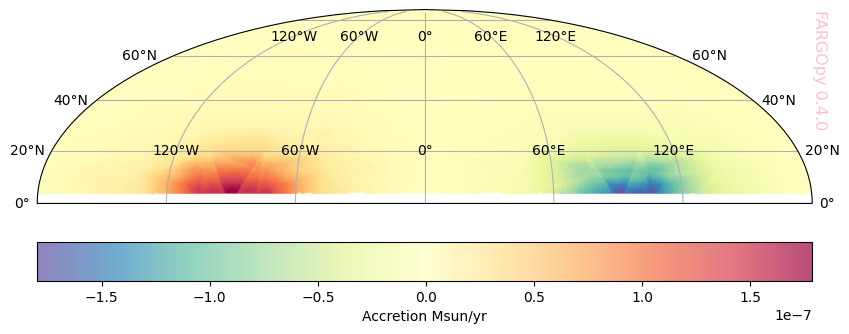

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


x0, y0, z0 = 1, 0, 0
xcs_shifted = xcs - x0
ycs_shifted = ycs - y0
zcs_shifted = zcs - z0


r = np.sqrt(xcs_shifted**2 + ycs_shifted**2 + zcs_shifted**2)
lat = np.degrees(np.arcsin(zcs_shifted / r))
lon = np.degrees(np.arctan2(ycs_shifted, xcs_shifted))


fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.Mollweide())
sc = ax.scatter(
    lon, lat, c=M_sy, s=2, cmap='Spectral_r',
    transform=ccrs.PlateCarree(), alpha=0.7
)

ax.gridlines(draw_labels=True)
fp.Plot.fargopy_mark(ax)
plt.colorbar(sc, orientation='horizontal', pad=0.05, label='Accretion Msun/yr')
plt.show()

## **Total Mass**

Now we can calculate the total mass accreted by the planet inside the sphere surface over the time.

In [47]:

planet0 = sim.load_planets(snapshot=snap)[0]
r_hill = planet0.hill_radius
x = planet0.pos.x
y = planet0.pos.y
z = planet0.pos.z   

sphere = fp.Surface(type='sphere',
    radius=0.5*r_hill, 
    subdivisions=6, 
    center=(x, y, z),
    z_cut=0.00203
)

In [49]:
mass = sphere.total_mass(
   sim=sim,
   snapshot=[0,10])   

In [50]:
mass = mass * sim.URHO * sim.UL**3  

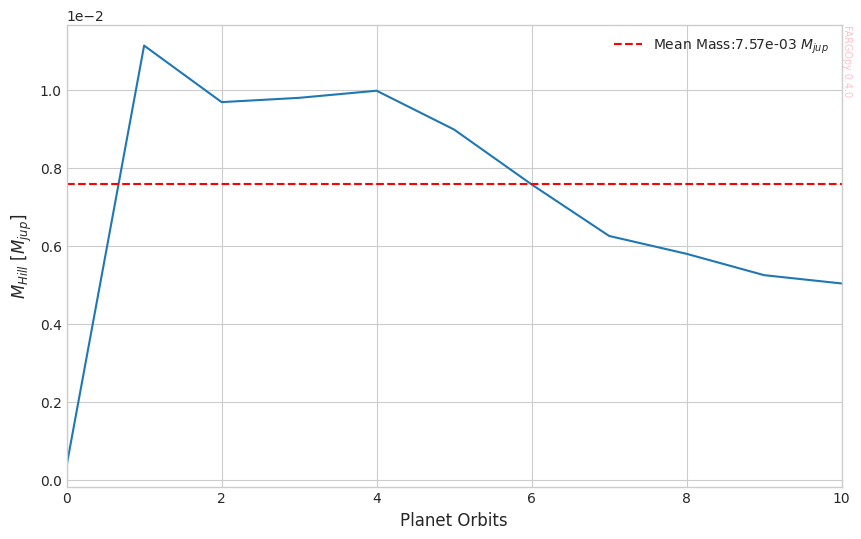

In [51]:
plt.style.use('seaborn-v0_8-whitegrid')
times = np.linspace(0, 10, 11)
Mjup = 1.989e27  # Jupiter mass Kg

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(times , np.array(mass) * 1e-3 / Mjup)
ax.hlines(
    y=np.median(np.array(mass) * 1e-3 / Mjup),
    xmin=0, xmax=10,
    color='r', linestyle='--',
    label=f'Mean Mass:{np.median(np.array(mass)*1e-3/Mjup):.2e} '+r'$M_{jup}$'
)
plt.xlabel('Planet Orbits', size=12)
plt.ylabel(r'$M_{Hill} \ [M_{jup}]$', size=12)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.xlim(0, 10)
fp.Plot.fargopy_mark(ax)
plt.legend()